# Mathematical Engineering - Financial Engineering, FY 2025-2026
# Buy Side - Exercise 3: Covariance Estimation Techniques & Statistical Factor Models


In [1]:
# Importing the libraries
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from utilities.backtest import backtest
from utilities.covariance_utilities import prepare_rolling_estimation_window
from utilities.portfolio_optimization import (
    mean_variance_portfolio,
    minimum_variance_portfolio,
)
from utilities.principal_component_analysis import (
    principal_component_analysis,
    align_eigenvectors_to_previous,
    pca_denoise_covariance,
)
from utilities.shrinkage import (
    constant_corr_shrinkage,
    market_factor_shrinkage,
)


In [2]:
# Reading the data
data_path = Path("data")  # !!! COMPLETE AS APPROPRIATE !!!

last_prices = pd.read_csv(
    data_path / "sx5e_underlyings.csv", index_col="Date", parse_dates=True
)

In [3]:
# Compute daily returns
performance = last_prices.pct_change().iloc[1:]

print(f"Dataset period: {performance.index[0].date()} to {performance.index[-1].date()}")
print(f"Number of observations: {len(performance)}")
print(f"Number of assets: {performance.shape[1]}")

Dataset period: 2013-01-03 to 2023-02-17
Number of observations: 2598
Number of assets: 50


/var/folders/lj/p8tjbxjn385dvb0v45qf_rlr0000gn/T/ipykernel_41050/1357904459.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  performance = last_prices.pct_change().iloc[1:]


In [4]:
# Parameters
time_horizon = 2 * 252  # 2 years of data for estimation
# Parameter determining the minimum coverage of returns required for an asset to be included
# in the optimization process
min_coverage = 0.95

In [5]:
# Get the last actual day in the data for each month (monthly rebalancing)
rebalance_dates = pd.DatetimeIndex(
    performance.groupby(pd.Grouper(freq="ME"))
    .apply(lambda x: x.index[-1] if len(x) > 0 else None)
    .dropna()
    .values
)

print(f"Number of rebalance dates: {len(rebalance_dates)}")
print(f"First rebalance: {rebalance_dates[0].date()}")
print(f"Last rebalance: {rebalance_dates[-1].date()}")

Number of rebalance dates: 122
First rebalance: 2013-01-31
Last rebalance: 2023-02-17


# Part I: Covariance Estimation

The sample covariance matrix is an unbiased estimator but can be noisy, especially when the number of observations $T$ is not much larger than the number of assets $N$. Shrinkage techniques improve estimation by combining the sample covariance with a structured target.

The shrunk covariance is computed as:
$$\hat{\Sigma}_{shrunk} = \delta \cdot F + (1 - \delta) \cdot S$$

where:
- $S$ is the sample covariance matrix
- $F$ is the structured target
- $\delta$ is the optimal shrinkage intensity (derived analytically)

a) Risk aversion parameter ($\gamma$) calibration.

In [6]:
mean_variance_risk_aversion = 1  # !!! COMPLETE AS APPROPRIATE !!!

calibration_date = None
for date in rebalance_dates:
    candidate_window = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=date,
        lookback=time_horizon,
        min_coverage=min_coverage,
    )
    if candidate_window.shape[0] == time_horizon and candidate_window.shape[1] > 0:
        calibration_date = date
        calibration_window = candidate_window
        break

if calibration_date is None:
    raise RuntimeError("No full estimation window available for portfolio checks")

calibration_sample_cov = calibration_window.cov()
calibration_expected_returns = calibration_window.mean(axis=0).values
ones = np.ones(calibration_sample_cov.shape[0])

def ge_error(lam):
    w = mean_variance_portfolio(
        expected_returns=calibration_expected_returns,
        cov_matrix=calibration_sample_cov.values,
        risk_aversion=lam,
    )
    return np.abs(w).sum() - 3.0

mean_variance_risk_aversion = brentq(ge_error, 0.01, 1000.0)
print(f"Calibrated risk aversion: {mean_variance_risk_aversion:.4f}")

calibration_mvp_weights = minimum_variance_portfolio(calibration_sample_cov.values)
calibration_mv_weights = mean_variance_portfolio(
    expected_returns=calibration_expected_returns,
    cov_matrix=calibration_sample_cov.values,
    risk_aversion=mean_variance_risk_aversion,
)

calibration_mvp_variance = float(
    calibration_mvp_weights @ calibration_sample_cov.values @ calibration_mvp_weights
)

np.testing.assert_allclose(calibration_mvp_weights.sum(), 1.0)
np.testing.assert_allclose(calibration_mv_weights.sum(), 1.0)

print(
    f"Closed-form checks on the {calibration_date.date()} rebalance window "
    f"({calibration_window.shape[1]} assets)"
)
pd.DataFrame(
    {
        "sum_weights": [calibration_mvp_weights.sum(), calibration_mv_weights.sum()],
        "in_sample_mean_return": [
            float(calibration_expected_returns @ calibration_mvp_weights),
            float(calibration_expected_returns @ calibration_mv_weights),
        ],
        "in_sample_volatility": [
            np.sqrt(calibration_mvp_variance),
            np.sqrt(
                float(
                    calibration_mv_weights
                    @ calibration_sample_cov.values
                    @ calibration_mv_weights
                )
            ),
        ],
        "gross_exposure": [
            np.abs(calibration_mvp_weights).sum(),
            np.abs(calibration_mv_weights).sum(),
        ],
    },
    index=["Minimum Variance", "Mean-Variance"],
)


Calibrated risk aversion: 180.1557
Closed-form checks on the 2014-12-31 rebalance window (46 assets)


,sum_weights,in_sample_mean_return,in_sample_volatility,gross_exposure
Minimum Variance,1.0,0.000481,0.006162,2.808149
Mean-Variance,1.0,0.000832,0.006318,3.000000


b-d) Shrinkage, minimum variance and mean variance portfolios

In [7]:
constant_corr_results = {}
mkt_factor_results = {}
sample_cov_min_var_ptfs = {}
constant_corr_cov_min_var_ptfs = {}
mkt_factor_cov_min_var_ptfs = {}
sample_cov_mean_var_ptfs = {}
constant_corr_cov_mean_var_ptfs = {}
mkt_factor_cov_mean_var_ptfs = {}
window_diagnostics = {}

for rebalance_date in rebalance_dates:
    cur_performance, cur_window_diagnostics = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=rebalance_date,
        lookback=time_horizon,
        min_coverage=min_coverage,
        return_diagnostics=True,
    )
    if (
        cur_window_diagnostics["row_count"] < time_horizon
        or cur_performance.shape[1] == 0
    ):
        continue

    print(
        f"Processing: {rebalance_date.date()} ({cur_performance.shape[1]} assets kept)"
    )
    reb_date = rebalance_date.to_pydatetime().date()

    # Market returns as equal-weighted average
    
    market_returns = cur_performance.mean(axis=1)
    estimated_expected_returns = cur_performance.mean(axis=0)

    # Compute shrinkage estimators
    cur_constant_corr_results = constant_corr_shrinkage(returns=cur_performance)
    cur_mkt_factor_results = market_factor_shrinkage(
        returns=cur_performance, market_returns=market_returns
    )

    # Compute closed-form portfolios for each covariance estimator
    sample_cov = cur_constant_corr_results["sample_cov"]
    constant_corr_cov = cur_constant_corr_results["shrunk_cov"]
    mkt_factor_cov = cur_mkt_factor_results["shrunk_cov"]

    for cov, cov_min_var_ptfs, cov_mean_var_ptfs in zip(
        [sample_cov, constant_corr_cov, mkt_factor_cov],
        [
            sample_cov_min_var_ptfs,
            constant_corr_cov_min_var_ptfs,
            mkt_factor_cov_min_var_ptfs,
        ],
        [
            sample_cov_mean_var_ptfs,
            constant_corr_cov_mean_var_ptfs,
            mkt_factor_cov_mean_var_ptfs,
        ],
    ):
        aligned_expected_returns = estimated_expected_returns.values
        cov_min_var_ptfs[reb_date] = pd.Series(
            data=minimum_variance_portfolio(cov.values), index=cov.index
        )
        cov_mean_var_ptfs[reb_date] = pd.Series(
            data=mean_variance_portfolio(
                expected_returns=aligned_expected_returns,
                cov_matrix=cov.values,
                risk_aversion=mean_variance_risk_aversion,
            ),
            index=cov.index,
        )

    constant_corr_results[reb_date] = cur_constant_corr_results
    mkt_factor_results[reb_date] = cur_mkt_factor_results
    window_diagnostics[reb_date] = cur_window_diagnostics


Processing: 2014-12-31 (46 assets kept)
Processing: 2015-01-30 (46 assets kept)
Processing: 2015-02-27 (46 assets kept)
Processing: 2015-03-31 (46 assets kept)
Processing: 2015-04-30 (46 assets kept)
Processing: 2015-05-29 (47 assets kept)
Processing: 2015-06-30 (47 assets kept)
Processing: 2015-07-31 (47 assets kept)
Processing: 2015-08-31 (47 assets kept)
Processing: 2015-09-30 (47 assets kept)
Processing: 2015-10-30 (47 assets kept)
Processing: 2015-11-30 (47 assets kept)
Processing: 2015-12-31 (47 assets kept)
Processing: 2016-01-29 (47 assets kept)
Processing: 2016-02-29 (47 assets kept)
Processing: 2016-03-31 (47 assets kept)
Processing: 2016-04-29 (47 assets kept)
Processing: 2016-05-31 (47 assets kept)
Processing: 2016-06-30 (47 assets kept)
Processing: 2016-07-29 (47 assets kept)
Processing: 2016-08-31 (47 assets kept)
Processing: 2016-09-30 (47 assets kept)
Processing: 2016-10-31 (47 assets kept)
Processing: 2016-11-30 (47 assets kept)
Processing: 2016-12-30 (47 assets kept)


d) Minimum variance portfolios out of sample evaluation

In [8]:
constant_corr_cov_min_var_ptf = pd.DataFrame(constant_corr_cov_min_var_ptfs).T.fillna(
    0.0
)
mkt_factor_cov_min_var_ptf = pd.DataFrame(mkt_factor_cov_min_var_ptfs).T.fillna(0.0)
sample_cov_min_var_ptf = pd.DataFrame(sample_cov_min_var_ptfs).T.fillna(0.0)


In [9]:
# Backtest portfolios
sample_cov_min_var_ptf_pfm = backtest(
    portfolios=sample_cov_min_var_ptf,
    returns=performance,
)
constant_corr_cov_min_var_ptf_pfm = backtest(
    portfolios=constant_corr_cov_min_var_ptf,
    returns=performance,
)
mkt_factor_cov_min_var_ptf_pfm = backtest(
    portfolios=mkt_factor_cov_min_var_ptf,
    returns=performance,
)

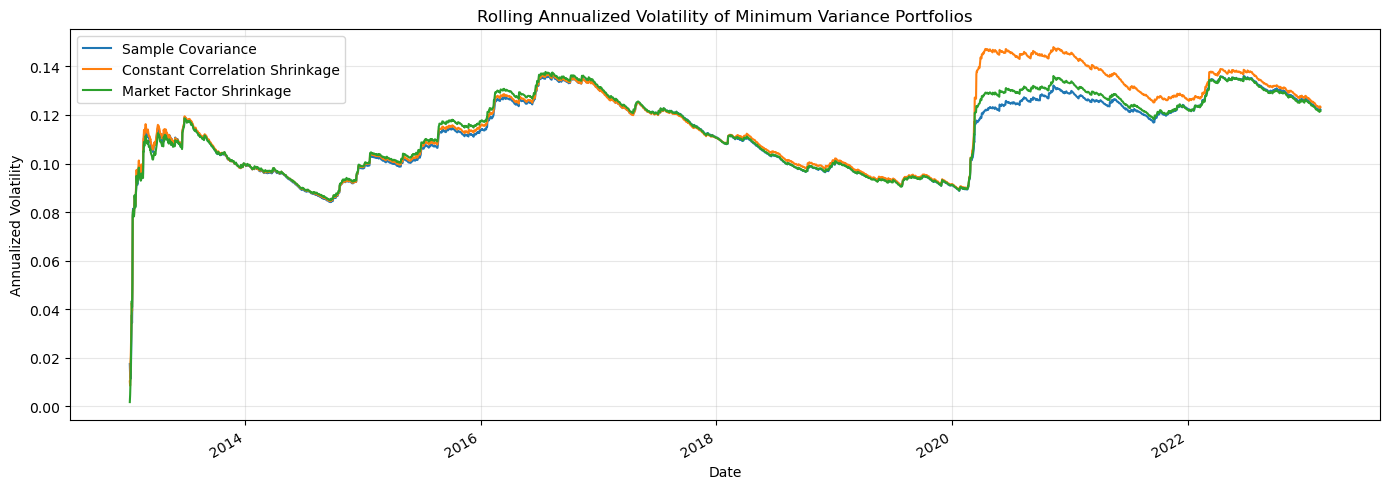

In [10]:
# Plot rolling annualized volatility
plt.figure(figsize=(14, 5))

(
    np.sqrt(252) * sample_cov_min_var_ptf_pfm.pct_change().ewm(span=time_horizon).std()
).plot(label="Sample Covariance", linewidth=1.5)

(
    np.sqrt(252)
    * constant_corr_cov_min_var_ptf_pfm.pct_change().ewm(span=time_horizon).std()
).plot(label="Constant Correlation Shrinkage", linewidth=1.5)

(
    np.sqrt(252)
    * mkt_factor_cov_min_var_ptf_pfm.pct_change().ewm(span=time_horizon).std()
).plot(label="Market Factor Shrinkage", linewidth=1.5)

plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.title("Rolling Annualized Volatility of Minimum Variance Portfolios")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

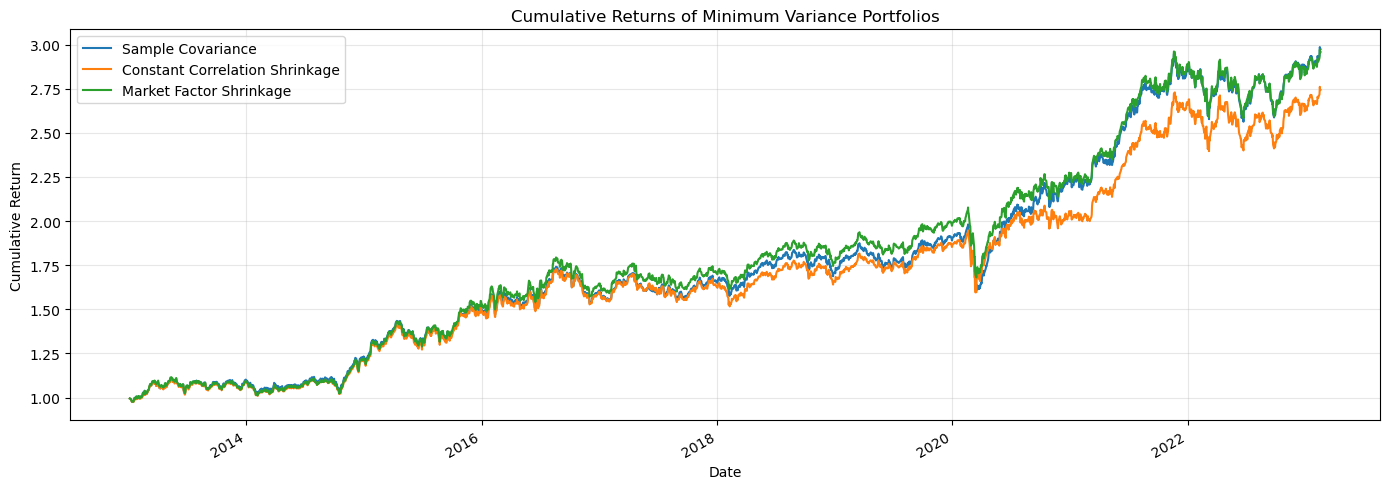

In [11]:
# Plot cumulative returns
plt.figure(figsize=(14, 5))

sample_cov_min_var_ptf_pfm.plot(label="Sample Covariance", linewidth=1.5)
constant_corr_cov_min_var_ptf_pfm.plot(
    label="Constant Correlation Shrinkage", linewidth=1.5
)
mkt_factor_cov_min_var_ptf_pfm.plot(label="Market Factor Shrinkage", linewidth=1.5)

plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Cumulative Returns of Minimum Variance Portfolios")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

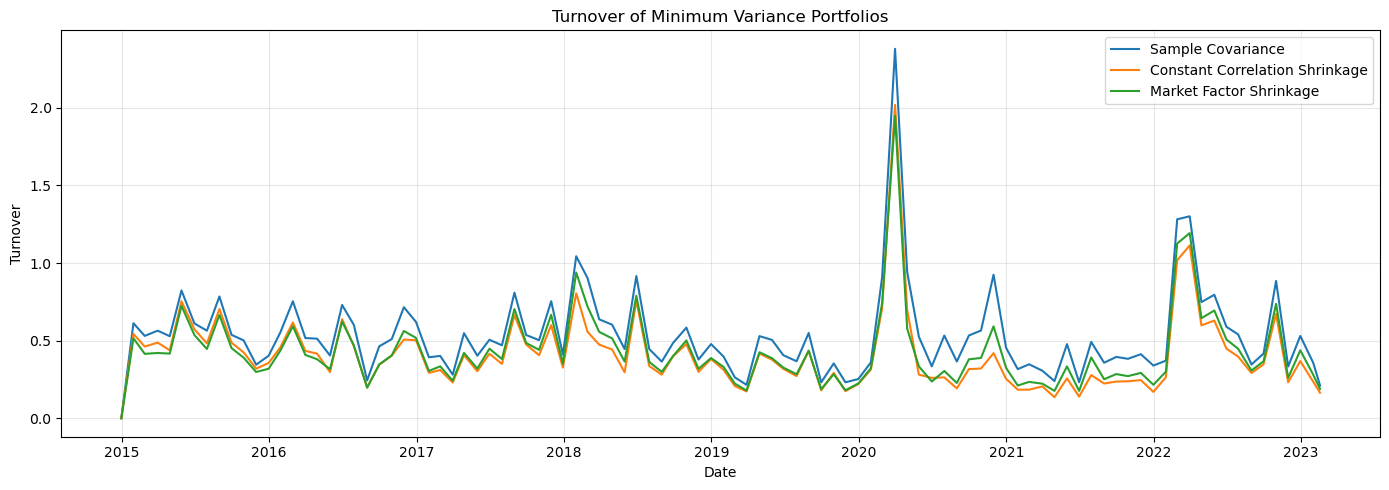

Average Turnover:
  Sample Covariance: 0.53
  Constant Corr Shrinkage: 0.41
  Market Factor Shrinkage: 0.43


In [12]:
# Plot gross exposure
plt.figure(figsize=(14, 5))

sample_cov_min_var_ptf.diff().abs().sum(axis=1).plot(
    label="Sample Covariance", linewidth=1.5
)
constant_corr_cov_min_var_ptf.diff().abs().sum(axis=1).plot(
    label="Constant Correlation Shrinkage", linewidth=1.5
)
mkt_factor_cov_min_var_ptf.diff().abs().sum(axis=1).plot(
    label="Market Factor Shrinkage", linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Turnover")
plt.title("Turnover of Minimum Variance Portfolios")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print turnover statistics
print("Average Turnover:")
print(
    f"  Sample Covariance: {sample_cov_min_var_ptf.diff().abs().sum(axis=1).mean():.2f}"
)
print(
    f"  Constant Corr Shrinkage: {constant_corr_cov_min_var_ptf.diff().abs().sum(axis=1).mean():.2f}"
)
print(
    f"  Market Factor Shrinkage: {mkt_factor_cov_min_var_ptf.diff().abs().sum(axis=1).mean():.2f}"
)

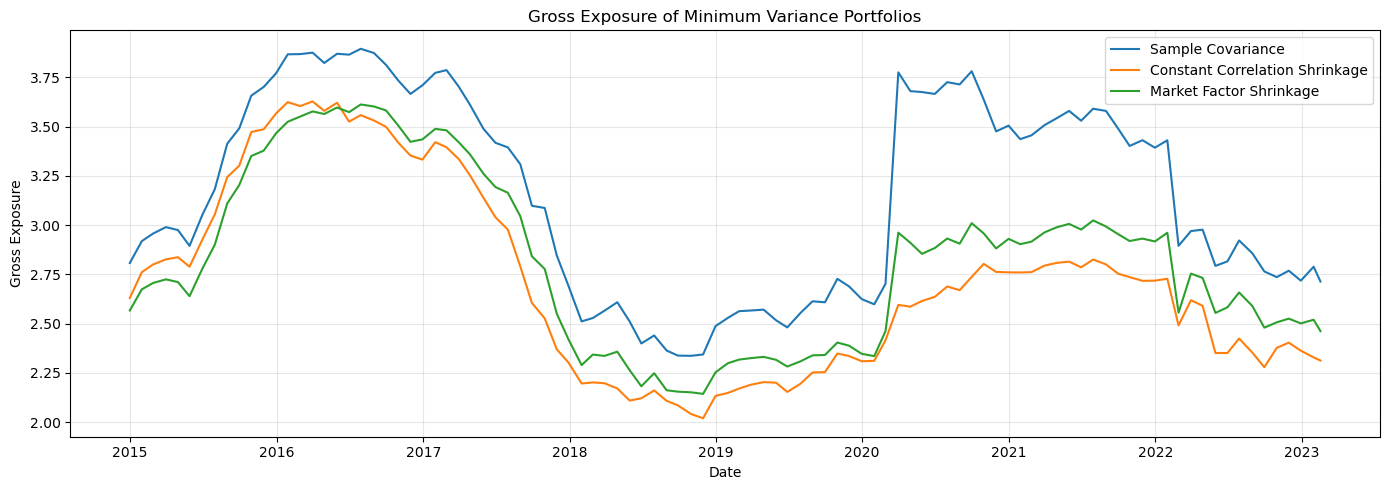

Average Gross Exposure:
  Sample Covariance: 3.16
  Constant Corr Shrinkage: 2.71
  Market Factor Shrinkage: 2.81


In [13]:
# Plot gross exposure
plt.figure(figsize=(14, 5))

sample_cov_min_var_ptf.abs().sum(axis=1).plot(label="Sample Covariance", linewidth=1.5)
constant_corr_cov_min_var_ptf.abs().sum(axis=1).plot(
    label="Constant Correlation Shrinkage", linewidth=1.5
)
mkt_factor_cov_min_var_ptf.abs().sum(axis=1).plot(
    label="Market Factor Shrinkage", linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Gross Exposure")
plt.title("Gross Exposure of Minimum Variance Portfolios")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print exposure statistics
print("Average Gross Exposure:")
print(f"  Sample Covariance: {sample_cov_min_var_ptf.abs().sum(axis=1).mean():.2f}")
print(
    f"  Constant Corr Shrinkage: {constant_corr_cov_min_var_ptf.abs().sum(axis=1).mean():.2f}"
)
print(
    f"  Market Factor Shrinkage: {mkt_factor_cov_min_var_ptf.abs().sum(axis=1).mean():.2f}"
)

d) Mean-variance portfolios out of sample evaluation


In [14]:
constant_corr_cov_mean_var_ptf = pd.DataFrame(constant_corr_cov_mean_var_ptfs).T.fillna(
    0.0
)
mkt_factor_cov_mean_var_ptf = pd.DataFrame(mkt_factor_cov_mean_var_ptfs).T.fillna(0.0)
sample_cov_mean_var_ptf = pd.DataFrame(sample_cov_mean_var_ptfs).T.fillna(0.0)


In [15]:
# Backtest portfolios
sample_cov_mean_var_ptf_pfm = backtest(
    portfolios=sample_cov_mean_var_ptf,
    returns=performance,
)
constant_corr_cov_mean_var_ptf_pfm = backtest(
    portfolios=constant_corr_cov_mean_var_ptf,
    returns=performance,
)
mkt_factor_cov_mean_var_ptf_pfm = backtest(
    portfolios=mkt_factor_cov_mean_var_ptf,
    returns=performance,
)


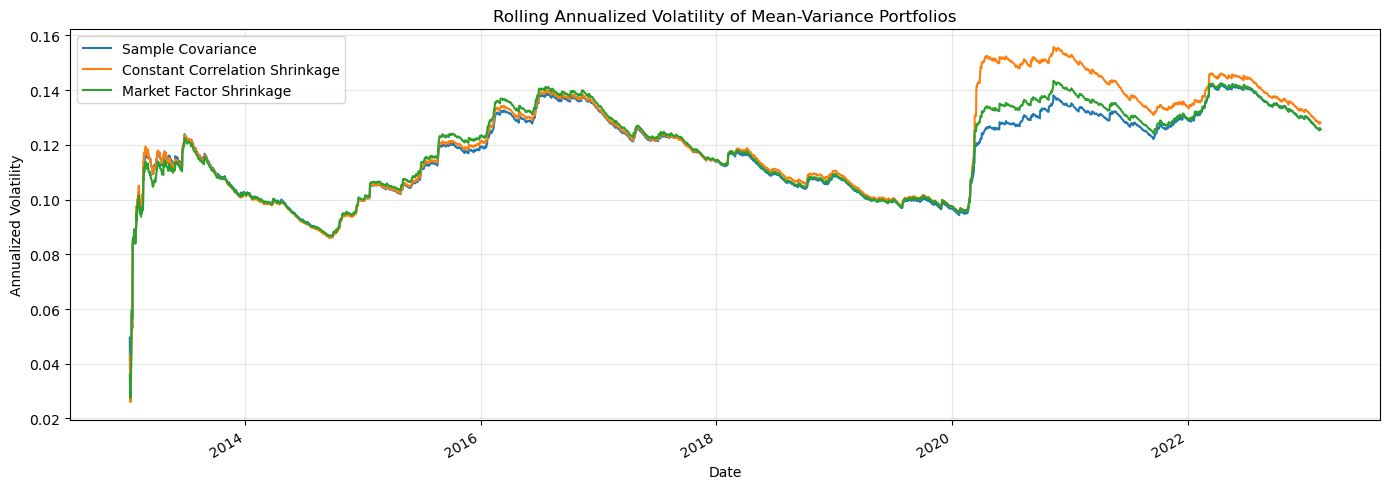

In [16]:
# Plot rolling annualized volatility
plt.figure(figsize=(14, 5))

(
    np.sqrt(252) * sample_cov_mean_var_ptf_pfm.pct_change().ewm(span=time_horizon).std()
).plot(label="Sample Covariance", linewidth=1.5)

(
    np.sqrt(252)
    * constant_corr_cov_mean_var_ptf_pfm.pct_change().ewm(span=time_horizon).std()
).plot(label="Constant Correlation Shrinkage", linewidth=1.5)

(
    np.sqrt(252)
    * mkt_factor_cov_mean_var_ptf_pfm.pct_change().ewm(span=time_horizon).std()
).plot(label="Market Factor Shrinkage", linewidth=1.5)

plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.title("Rolling Annualized Volatility of Mean-Variance Portfolios")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


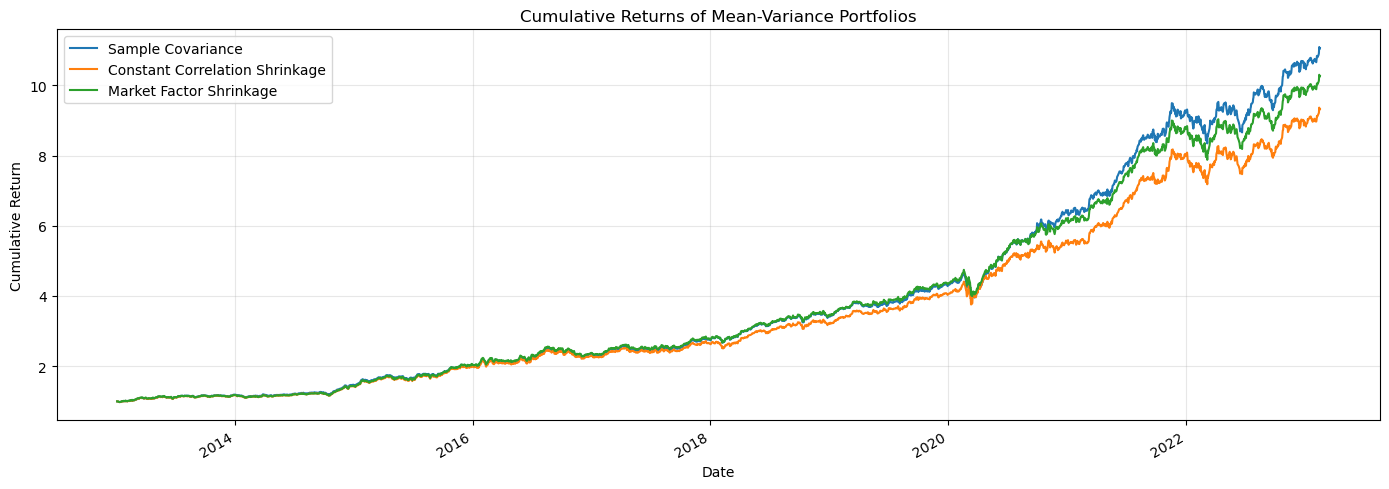

In [17]:
# Plot cumulative returns
plt.figure(figsize=(14, 5))

sample_cov_mean_var_ptf_pfm.plot(label="Sample Covariance", linewidth=1.5)
constant_corr_cov_mean_var_ptf_pfm.plot(
    label="Constant Correlation Shrinkage", linewidth=1.5
)
mkt_factor_cov_mean_var_ptf_pfm.plot(label="Market Factor Shrinkage", linewidth=1.5)

plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Cumulative Returns of Mean-Variance Portfolios")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


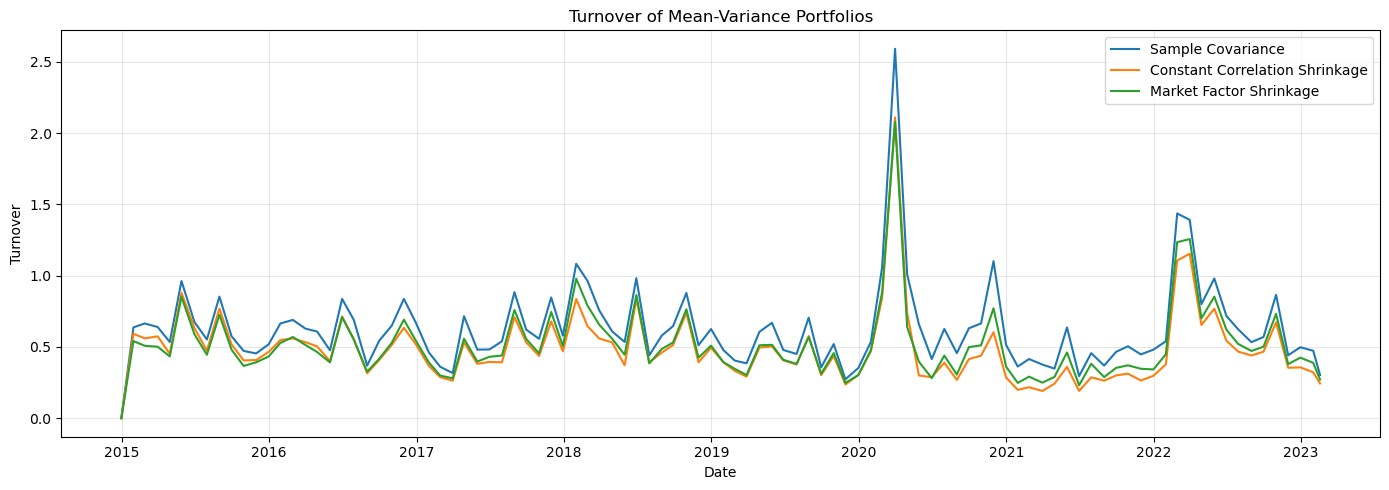

Average Turnover:
  Sample Covariance: 0.63
  Constant Corr Shrinkage: 0.49
  Market Factor Shrinkage: 0.51


In [18]:
# Plot gross exposure
plt.figure(figsize=(14, 5))

sample_cov_mean_var_ptf.diff().abs().sum(axis=1).plot(
    label="Sample Covariance", linewidth=1.5
)
constant_corr_cov_mean_var_ptf.diff().abs().sum(axis=1).plot(
    label="Constant Correlation Shrinkage", linewidth=1.5
)
mkt_factor_cov_mean_var_ptf.diff().abs().sum(axis=1).plot(
    label="Market Factor Shrinkage", linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Turnover")
plt.title("Turnover of Mean-Variance Portfolios")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print turnover statistics
print("Average Turnover:")
print(
    f"  Sample Covariance: {sample_cov_mean_var_ptf.diff().abs().sum(axis=1).mean():.2f}"
)
print(
    f"  Constant Corr Shrinkage: {constant_corr_cov_mean_var_ptf.diff().abs().sum(axis=1).mean():.2f}"
)
print(
    f"  Market Factor Shrinkage: {mkt_factor_cov_mean_var_ptf.diff().abs().sum(axis=1).mean():.2f}"
)

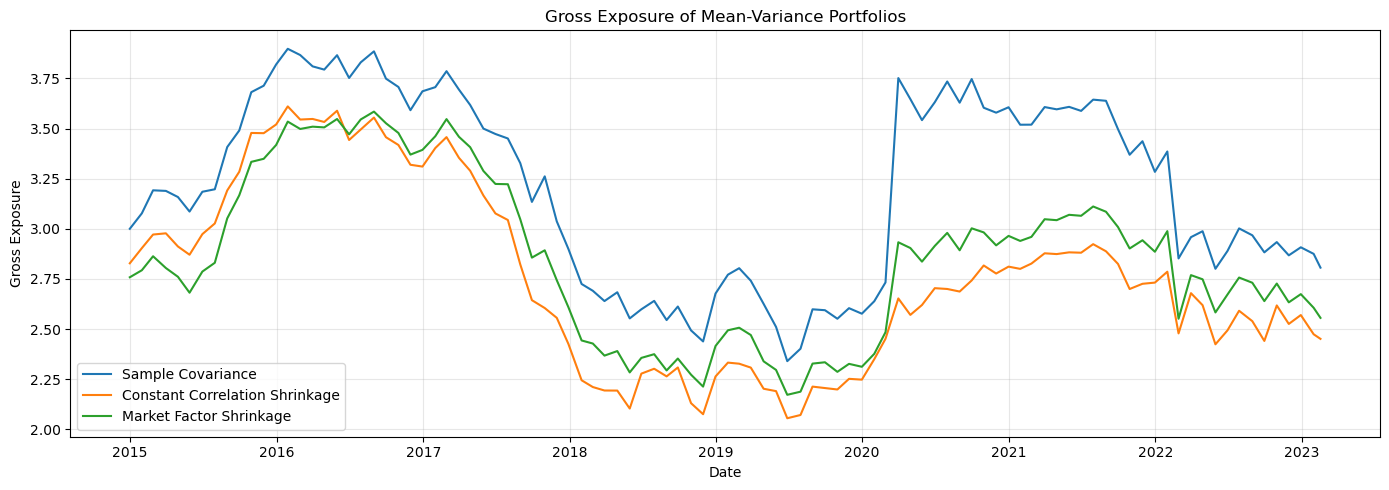

Average Gross Exposure:
  Sample Covariance: 3.20
  Constant Corr Shrinkage: 2.76
  Market Factor Shrinkage: 2.85


In [19]:
# Plot gross exposure
plt.figure(figsize=(14, 5))

sample_cov_mean_var_ptf.abs().sum(axis=1).plot(label="Sample Covariance", linewidth=1.5)
constant_corr_cov_mean_var_ptf.abs().sum(axis=1).plot(
    label="Constant Correlation Shrinkage", linewidth=1.5
)
mkt_factor_cov_mean_var_ptf.abs().sum(axis=1).plot(
    label="Market Factor Shrinkage", linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Gross Exposure")
plt.title("Gross Exposure of Mean-Variance Portfolios")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print exposure statistics
print("Average Gross Exposure:")
print(f"  Sample Covariance: {sample_cov_mean_var_ptf.abs().sum(axis=1).mean():.2f}")
print(
    f"  Constant Corr Shrinkage: {constant_corr_cov_mean_var_ptf.abs().sum(axis=1).mean():.2f}"
)
print(
    f"  Market Factor Shrinkage: {mkt_factor_cov_mean_var_ptf.abs().sum(axis=1).mean():.2f}"
)


Shrinkage intensity

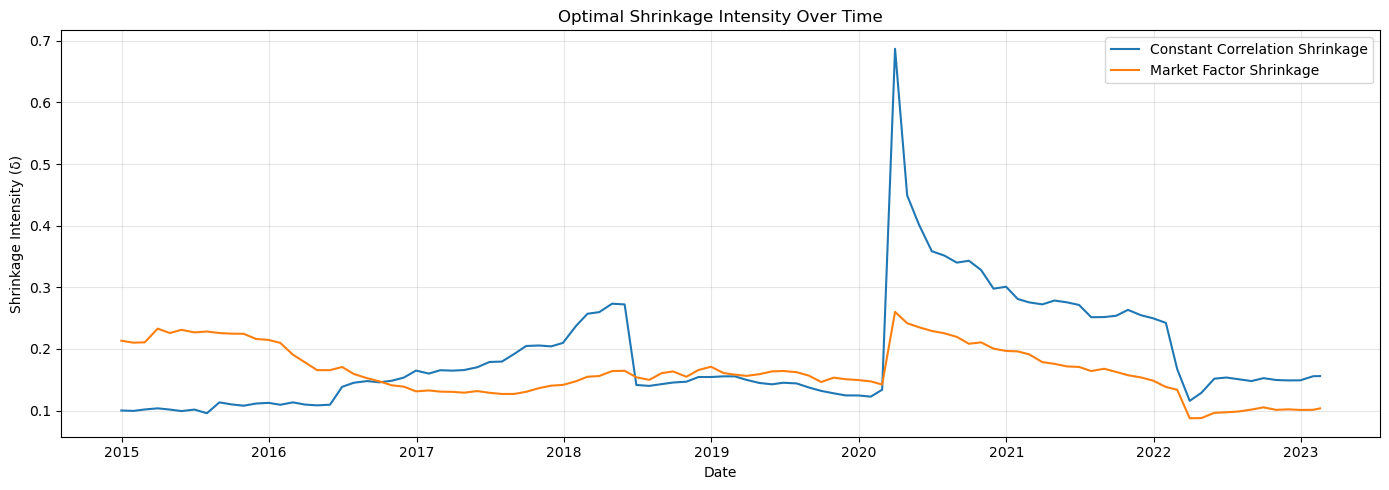

Constant Correlation Shrinkage Intensity:
  Mean: 18.82%
  Std: 9.15%

Market Factor Shrinkage Intensity:
  Mean: 16.39%
  Std: 4.03%


In [20]:
# Plot shrinkage intensity over time
plt.figure(figsize=(14, 5))

pd.Series(
    {date: results["intensity"] for date, results in constant_corr_results.items()}
).plot(label="Constant Correlation Shrinkage", linewidth=1.5)

pd.Series(
    {date: results["intensity"] for date, results in mkt_factor_results.items()}
).plot(label="Market Factor Shrinkage", linewidth=1.5)

plt.xlabel("Date")
plt.ylabel("Shrinkage Intensity (δ)")
plt.title("Optimal Shrinkage Intensity Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
const_corr_intensity = pd.Series(
    {date: results["intensity"] for date, results in constant_corr_results.items()}
)
mkt_factor_intensity = pd.Series(
    {date: results["intensity"] for date, results in mkt_factor_results.items()}
)

print("Constant Correlation Shrinkage Intensity:")
print(f"  Mean: {const_corr_intensity.mean():.2%}")
print(f"  Std: {const_corr_intensity.std():.2%}")
print("\nMarket Factor Shrinkage Intensity:")
print(f"  Mean: {mkt_factor_intensity.mean():.2%}")
print(f"  Std: {mkt_factor_intensity.std():.2%}")

Condition Number


In [21]:
sample_cov_cond = {
    date: np.linalg.cond(results["sample_cov"].values)
    for date, results in constant_corr_results.items()
}
constant_corr_cond = {
    date: np.linalg.cond(results["shrunk_cov"].values)
    for date, results in constant_corr_results.items()
}
mkt_factor_cond = {
    date: np.linalg.cond(results["shrunk_cov"].values)
    for date, results in mkt_factor_results.items()
}

eligible_asset_counts = pd.Series(
    {
        date: diagnostics["asset_count_after_filter"]
        for date, diagnostics in window_diagnostics.items()
    }
)


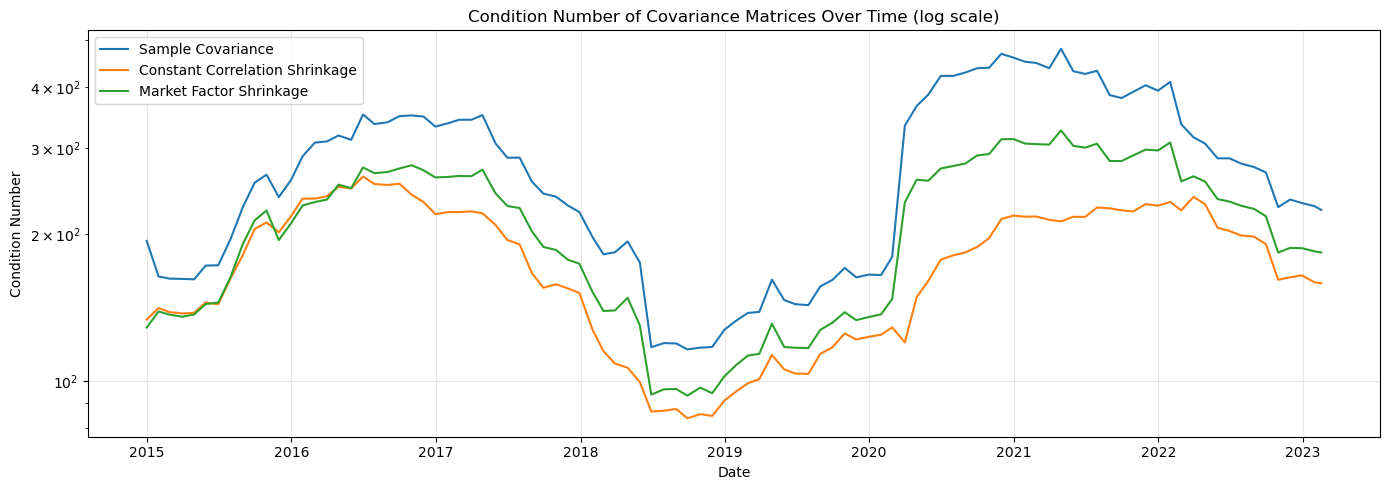

Condition Number Statistics:
  Sample Covariance - Mean: 273.4
  Constant Corr Shrinkage - Mean: 174.2
  Market Factor Shrinkage - Mean: 208.2
  Average number of eligible assets: 47.9


In [22]:
# Plot condition numbers
plt.figure(figsize=(14, 5))

pd.Series(sample_cov_cond).plot(label="Sample Covariance", linewidth=1.5)
pd.Series(constant_corr_cond).plot(
    label="Constant Correlation Shrinkage", linewidth=1.5
)
pd.Series(mkt_factor_cond).plot(label="Market Factor Shrinkage", linewidth=1.5)

plt.xlabel("Date")
plt.ylabel("Condition Number")
plt.yscale("log")
plt.title("Condition Number of Covariance Matrices Over Time (log scale)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
print("Condition Number Statistics:")
print(f"  Sample Covariance - Mean: {np.mean(list(sample_cov_cond.values())):.1f}")
print(
    f"  Constant Corr Shrinkage - Mean: {np.mean(list(constant_corr_cond.values())):.1f}"
)
print(
    f"  Market Factor Shrinkage - Mean: {np.mean(list(mkt_factor_cond.values())):.1f}"
)
print(f"  Average number of eligible assets: {eligible_asset_counts.mean():.1f}")


# Part II: Statistical Factor Model

Principal Component Analysis (PCA) extracts the dominant risk factors from the correlation/covariance matrix. The first principal component typically represents the market factor, explaining a large portion of total variance.

Key properties of PCA:
- Eigenvalues represent variance explained by each component
- Eigenvectors represent factor loadings (exposures of each asset to the factor)
- Components are orthogonal (uncorrelated)

a) PCA

In [23]:
eig_vals = {}
eig_vecs = {}
cosine_distances = {}
max_cosine_distances = {}

prev_eig_vecs = None
for rebalance_date in rebalance_dates:
    cur_performance = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=rebalance_date,
        lookback=time_horizon,
        min_coverage=min_coverage,
    )
    if cur_performance.shape[0] < time_horizon or cur_performance.shape[1] == 0:
        continue

    print(
        f"Processing: {rebalance_date.date()} ({cur_performance.shape[1]} assets kept)"
    )
    reb_date = rebalance_date.to_pydatetime().date()

    # Compute covariance matrix and PCA
    sample_cov = cur_performance.cov()
    cur_eig_vals, cur_eig_vecs = principal_component_analysis(sample_cov.values)

    cur_eig_vals = pd.Series(
        data=cur_eig_vals.flatten(), index=range(len(cur_eig_vals))
    )
    cur_eig_vecs = pd.DataFrame(
        data=cur_eig_vecs,
        index=cur_performance.columns,
        columns=range(cur_eig_vecs.shape[1]),
    )
    cur_eig_vecs = align_eigenvectors_to_previous(cur_eig_vecs, prev_eig_vecs)

    # Compute cosine similarity between consecutive periods after sign alignment
    if prev_eig_vecs is not None:
        common_assets = cur_eig_vecs.index.intersection(prev_eig_vecs.index)
        components_num = min(
            len(common_assets),
            cur_eig_vecs.shape[1],
            prev_eig_vecs.shape[1],
        )

        a = cur_eig_vecs.loc[common_assets].iloc[:, :components_num]
        b = prev_eig_vecs.loc[common_assets].iloc[:, :components_num]
        pc_proximity = a.T @ b

        cosine_distances[reb_date] = pd.Series(
            data=np.diag(pc_proximity),
            index=pc_proximity.index,
        )
        max_cosine_distances[reb_date] = pd.Series(
            data=pc_proximity.abs().max(axis=1).values.flatten(),
            index=pc_proximity.index,
        )

    prev_eig_vecs = cur_eig_vecs
    eig_vals[reb_date] = cur_eig_vals
    eig_vecs[reb_date] = cur_eig_vecs


Processing: 2014-12-31 (46 assets kept)
Processing: 2015-01-30 (46 assets kept)
Processing: 2015-02-27 (46 assets kept)
Processing: 2015-03-31 (46 assets kept)
Processing: 2015-04-30 (46 assets kept)
Processing: 2015-05-29 (47 assets kept)
Processing: 2015-06-30 (47 assets kept)
Processing: 2015-07-31 (47 assets kept)
Processing: 2015-08-31 (47 assets kept)
Processing: 2015-09-30 (47 assets kept)
Processing: 2015-10-30 (47 assets kept)
Processing: 2015-11-30 (47 assets kept)
Processing: 2015-12-31 (47 assets kept)
Processing: 2016-01-29 (47 assets kept)
Processing: 2016-02-29 (47 assets kept)
Processing: 2016-03-31 (47 assets kept)
Processing: 2016-04-29 (47 assets kept)
Processing: 2016-05-31 (47 assets kept)
Processing: 2016-06-30 (47 assets kept)
Processing: 2016-07-29 (47 assets kept)
Processing: 2016-08-31 (47 assets kept)
Processing: 2016-09-30 (47 assets kept)
Processing: 2016-10-31 (47 assets kept)
Processing: 2016-11-30 (47 assets kept)
Processing: 2016-12-30 (47 assets kept)


b) Results discussion

Cosine similarity evolution after sign alignment

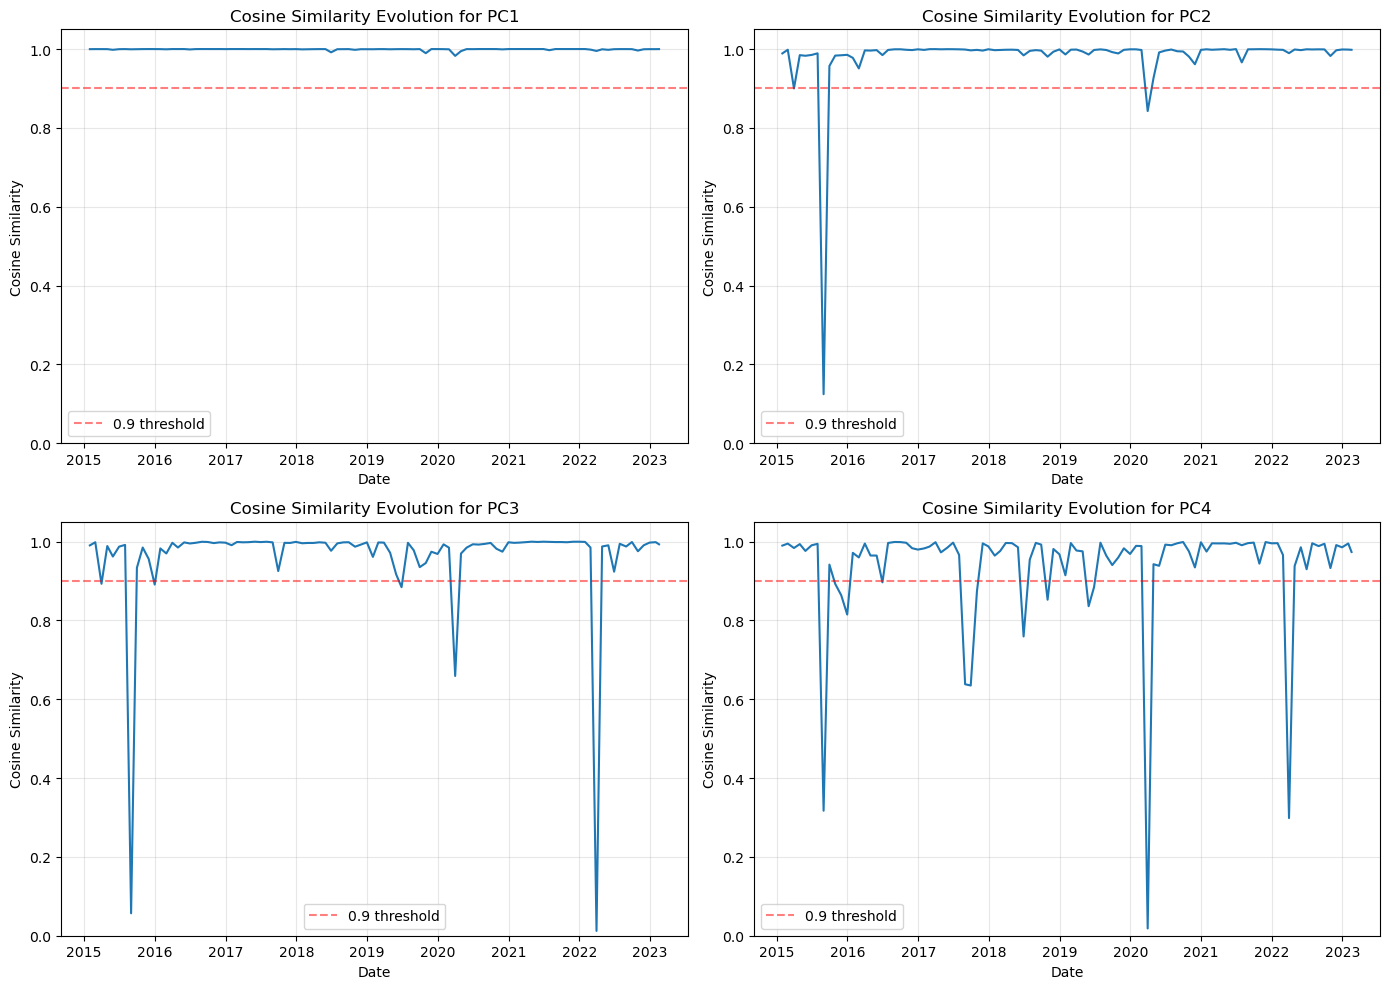

In [24]:
# Plot cosine similarity evolution for the first few PCs
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, pc in enumerate([0, 1, 2, 3]):
    ax = axes[idx // 2, idx % 2]

    cosine_series = pd.Series(
        {
            date: cosine_distance[pc]
            for date, cosine_distance in cosine_distances.items()
        }
    )
    cosine_series.plot(ax=ax, linewidth=1.5)

    ax.set_xlabel("Date")
    ax.set_ylabel("Cosine Similarity")
    ax.set_title(f"Cosine Similarity Evolution for PC{pc + 1}")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)
    ax.axhline(y=0.9, color="r", linestyle="--", alpha=0.5, label="0.9 threshold")
    ax.legend()

plt.tight_layout()
plt.show()


Explained variance evolution

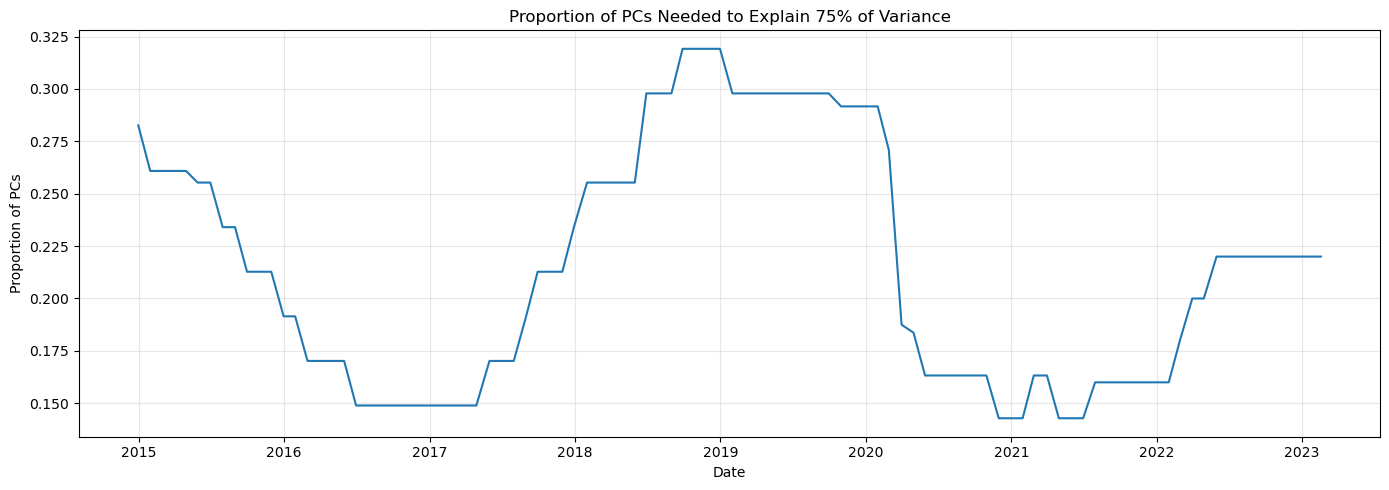

Statistics:
  Mean proportion: 21.43%
  Min proportion: 14.29%
  Max proportion: 31.91%


In [25]:
# Plot the proportion of PCs needed to explain a given variance threshold
var_threshold = 0.75

plt.figure(figsize=(14, 5))

pc_proportion = pd.Series(
    {
        date: (np.searchsorted(np.cumsum(cur_eig_vals / cur_eig_vals.sum()), var_threshold) + 1) / len(cur_eig_vals)
        for date, cur_eig_vals in eig_vals.items()
    }
)
pc_proportion.plot(linewidth=1.5)

plt.xlabel("Date")
plt.ylabel("Proportion of PCs")
plt.title(f"Proportion of PCs Needed to Explain {var_threshold * 100:.0f}% of Variance")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Statistics:")
print(f"  Mean proportion: {pc_proportion.mean():.2%}")
print(f"  Min proportion: {pc_proportion.min():.2%}")
print(f"  Max proportion: {pc_proportion.max():.2%}")

PCs interpretation

The factor loadings (eigenvector components) can be interpreted to understand what each PC represents. Typically:
- **PC1**: Market factor (similar loadings across all assets)
- **PC2+**: Sector/style factors (long-short patterns)

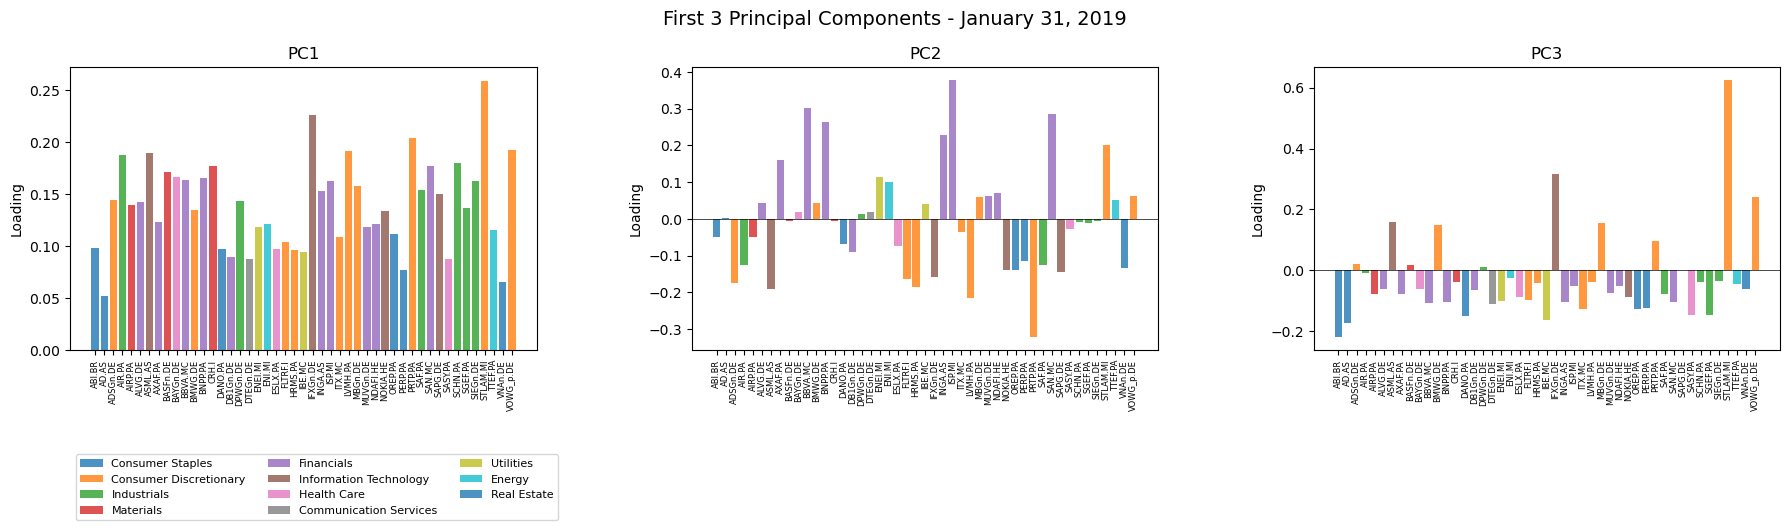

In [26]:
# Load sector data
ticker_details = pd.read_csv(data_path / "ticker_details.csv")
sector_map = ticker_details.set_index("Ticker")["GICS"]
# Get eigenvectors at Jan 31, 2019
import datetime
ref_date = datetime.date(2019, 1, 31)
ref_eig_vecs = eig_vecs[ref_date]

# Map sectors to assets
sectors = sector_map.reindex(ref_eig_vecs.index)

# Plot first 3 PCs
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for pc_idx in range(3):
    ax = axes[pc_idx]
    loadings = ref_eig_vecs.iloc[:, pc_idx]
    
    for sector in sectors.dropna().unique():
        mask = sectors == sector
        ax.bar(
            np.where(mask)[0],
            loadings[mask],
            label=sector,
            alpha=0.8,
        )
    
    ax.set_title(f"PC{pc_idx + 1}")
    ax.set_ylabel("Loading")
    ax.axhline(y=0, color="black", linewidth=0.5)
    ax.set_xticks(range(len(loadings)))
    ax.set_xticklabels(loadings.index, rotation=90, fontsize=6)

axes[0].legend(bbox_to_anchor=(0, -0.35), loc="upper left", ncol=3, fontsize=8)
plt.suptitle("First 3 Principal Components - January 31, 2019", fontsize=14)
plt.tight_layout()
plt.show()

# Part III: Connecting the Dots

Shrinkage and PCA-based denoising both address the same problem — the sample covariance matrix is noisy when $T/N$ is not large. They do so in complementary ways:

- **Shrinkage** blends the sample covariance with a structured target, pulling extreme (noisy) eigenvalues toward a common level.
- **PCA denoising** keeps the $k$ largest eigenvalues intact (signal) and replaces the remaining $N - k$ eigenvalues with their average (noise floor), then reconstructs: $$\hat{\Sigma}_{denoised} = \sum_{i=1}^{k} \lambda_i \mathbf{v}_i \mathbf{v}_i^\top + \bar{\lambda}_{noise} \sum_{i=k+1}^{N} \mathbf{v}_i \mathbf{v}_i^\top$$

a) PCA-based denoising of the covariance matrix

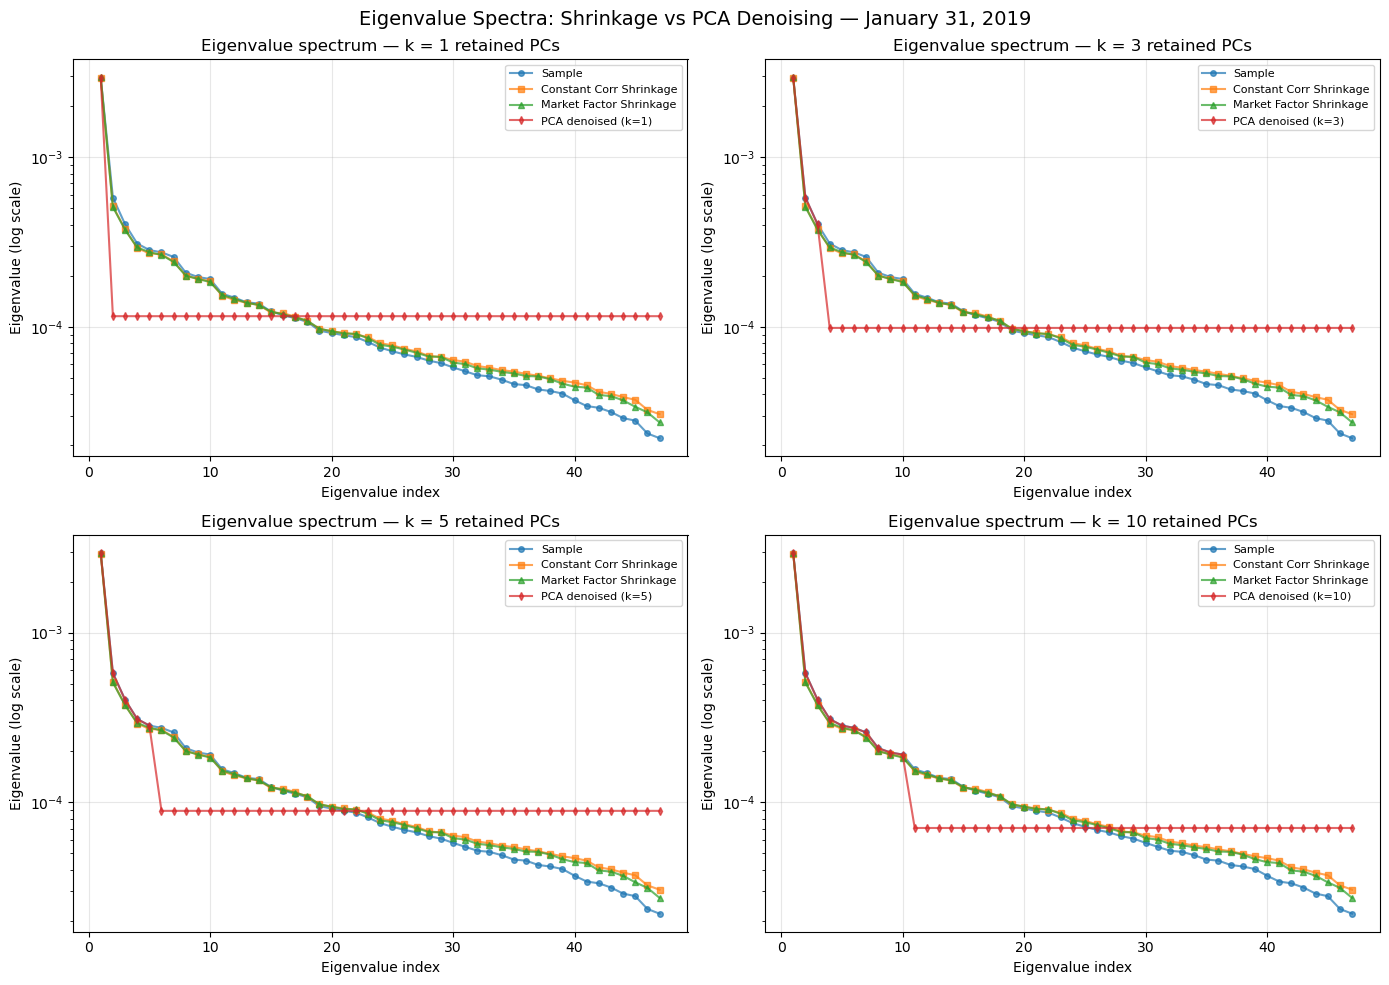

Constant Correlation shrinkage intensity: 0.1556
Market Factor shrinkage intensity: 0.1610


In [27]:
import datetime

ref_date = datetime.date(2019, 1, 31)

# Get sample covariance and shrunk matrices at reference date
sample_cov = constant_corr_results[ref_date]["sample_cov"].values
cc_shrunk = constant_corr_results[ref_date]["shrunk_cov"].values
mf_shrunk = mkt_factor_results[ref_date]["shrunk_cov"].values

# Eigenvalues of sample and shrunk matrices
eig_sample, _ = principal_component_analysis(sample_cov)
eig_cc, _ = principal_component_analysis(cc_shrunk)
eig_mf, _ = principal_component_analysis(mf_shrunk)

# PCA denoising for k in {1, 3, 5, 10}
k_values = [1, 3, 5, 10]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, k in enumerate(k_values):
    ax = axes[idx // 2, idx % 2]
    
    denoised_cov, denoised_eig_vals = pca_denoise_covariance(sample_cov, k)
    
    n = len(eig_sample)
    x = np.arange(1, n + 1)
    
    ax.semilogy(x, eig_sample, 'o-', label='Sample', markersize=4, alpha=0.7)
    ax.semilogy(x, eig_cc, 's-', label='Constant Corr Shrinkage', markersize=4, alpha=0.7)
    ax.semilogy(x, eig_mf, '^-', label='Market Factor Shrinkage', markersize=4, alpha=0.7)
    ax.semilogy(x, denoised_eig_vals, 'd-', label=f'PCA denoised (k={k})', markersize=4, alpha=0.7)
    
    ax.set_xlabel("Eigenvalue index")
    ax.set_ylabel("Eigenvalue (log scale)")
    ax.set_title(f"Eigenvalue spectrum — k = {k} retained PCs")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Eigenvalue Spectra: Shrinkage vs PCA Denoising — January 31, 2019", fontsize=14)
plt.tight_layout()
plt.show()

# Print shrinkage intensities at reference date
print(f"Constant Correlation shrinkage intensity: {constant_corr_results[ref_date]['intensity']:.4f}")
print(f"Market Factor shrinkage intensity: {mkt_factor_results[ref_date]['intensity']:.4f}")